In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
orders_rec   = pd.read_csv('olist_augmented_data/orders_augmented.csv')
items_rec    = pd.read_csv('olist_augmented_data/order_items_augmented.csv')
products_rec = pd.read_csv('olist_processed_data/products_cleaned.csv')
category_rec = pd.read_csv('olist_processed_data/category_translation_cleaned.csv')

orders_rec = orders_rec[orders_rec['order_status'] == 'delivered']


df_rec = items_rec.merge(orders_rec[['order_id', 'customer_id']], on='order_id', how='inner')

df_rec = df_rec.merge(products_rec[['product_id', 'product_category_name']], on='product_id', how='left')

df_rec = df_rec.merge(category_rec, on='product_category_name', how='left')

df_rec['category'] = df_rec['product_category_name_english'].fillna(df_rec['product_category_name'])
df_rec['category'] = df_rec['category'].fillna('unknown')

print(f"Total Orders : {df_rec['order_id'].nunique()}")
print(f"Total products     : {df_rec['product_id'].nunique()}")
print(f"Total categories   : {df_rec['category'].nunique()}")
df_rec.head()

Total Orders : 135312
Total products     : 32893
Total categories   : 74


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,product_category_name,product_category_name_english,category
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,cool_stuff,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,pet_shop,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,moveis_decoracao,furniture_decor,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,perfumaria,perfumery,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,ferramentas_jardim,garden_tools,garden_tools


In [3]:
basket = df_rec.groupby(['order_id', 'category'])['product_id'].count().unstack(fill_value=0)

basket.head()

category,agro_industry_and_commerce,air_conditioning,art,arts_and_craftmanship,audio,auto,baby,bed_bath_table,books_general_interest,books_imported,...,signaling_and_security,small_appliances,small_appliances_home_oven_and_coffee,sports_leisure,stationery,tablets_printing_image,telephony,toys,unknown,watches_gifts
order_id,,,,,,,,,,,,,,,,,,,,,
00010242fe8c5a6d1ba2dd792cb16214,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00018f77f2f0320c557190d7a144bdd3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
000229ec398224ef6ca0657da4fc703e,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00024acbcdf0a6daa1e931b038114c75,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00042b26cf59d7ce69dfabb4e55b4fd9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
basket_binary = basket.map(lambda x: 1 if x > 0 else 0)

print(f"Basket matrix shape : {basket_binary.shape}")
print(f"  Orders (rows)     : {basket_binary.shape[0]}")
print(f"  Categories (cols) : {basket_binary.shape[1]}")
print(f"\nSparsity: {(basket_binary == 0).sum().sum() / basket_binary.size * 100:.1f}% zeros")
print(f"\nSample:")
basket_binary.iloc[:10, :12]

Basket matrix shape : (135312, 74)
  Orders (rows)     : 135312
  Categories (cols) : 74

Sparsity: 98.3% zeros

Sample:


category,agro_industry_and_commerce,air_conditioning,art,arts_and_craftmanship,audio,auto,baby,bed_bath_table,books_general_interest,books_imported,books_technical,cds_dvds_musicals
order_id,,,,,,,,,,,,
00010242fe8c5a6d1ba2dd792cb16214,0,0,0,0,0,0,0,0,0,0,0,0
00018f77f2f0320c557190d7a144bdd3,0,0,0,0,0,0,0,0,0,0,0,0
000229ec398224ef6ca0657da4fc703e,0,0,0,0,0,0,0,0,0,0,0,0
00024acbcdf0a6daa1e931b038114c75,0,0,0,0,0,0,0,0,0,0,0,0
00042b26cf59d7ce69dfabb4e55b4fd9,0,0,0,0,0,0,0,0,0,0,0,0
00047df997b94f62a99c6a6a974fc9f5,0,0,0,0,0,1,0,0,0,0,0,0
00048cc3ae777c65dbb7d2a0634bc1ea,0,0,0,0,0,0,0,0,0,0,0,0
00054e8431b9d7675808bcb819fb4a32,0,0,0,0,0,0,0,0,0,0,0,0
000576fe39319847cbb9d288c5617fa6,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
multi_category_orders = basket_binary[basket_binary.sum(axis=1) > 1]
print(f"Orders with 2+ categories: {len(multi_category_orders)} ({len(multi_category_orders)/len(basket_binary)*100:.1f}%)")


co_occurrence = multi_category_orders.T.dot(multi_category_orders)

co_occurrence = co_occurrence.astype(float)
for cat in co_occurrence.columns:
    co_occurrence.loc[cat, cat] = 0

print(f"\nCo-occurrence matrix shape: {co_occurrence.shape}")
print(f"\nTop category pairs:")

co_occurrence.index.name = 'category_1'
co_occurrence.columns.name = 'category_2'
co_pairs = co_occurrence.stack().reset_index()
co_pairs.columns = ['category_1', 'category_2', 'co_count']
co_pairs = co_pairs[co_pairs['co_count'] > 0].sort_values('co_count', ascending=False)
co_pairs = co_pairs[co_pairs['category_1'] < co_pairs['category_2']]  # remove duplicates
print(co_pairs.head(20).to_string(index=False))

Orders with 2+ categories: 26085 (19.3%)

Co-occurrence matrix shape: (74, 74)

Top category pairs:
           category_1            category_2  co_count
       bed_bath_table       furniture_decor     795.0
       bed_bath_table        sports_leisure     775.0
      furniture_decor        sports_leisure     681.0
       bed_bath_table         health_beauty     655.0
           housewares        sports_leisure     632.0
       bed_bath_table            housewares     628.0
        health_beauty        sports_leisure     617.0
      furniture_decor            housewares     582.0
      furniture_decor         health_beauty     566.0
        health_beauty            housewares     529.0
                 auto        bed_bath_table     506.0
                 auto        sports_leisure     497.0
       bed_bath_table computers_accessories     488.0
                 auto       furniture_decor     449.0
computers_accessories        sports_leisure     432.0
computers_accessories       furnitur

In [6]:
category_counts = basket_binary.sum(axis=0)

rules_list = []
for _, row in co_pairs.iterrows():
    cat_a = row['category_1']
    cat_b = row['category_2']
    co_count = row['co_count']


    conf_ab = co_count / category_counts[cat_a]
    lift_ab = conf_ab / (category_counts[cat_b] / len(basket_binary))
    rules_list.append({
        'antecedents' : cat_a,
        'consequents' : cat_b,
        'co_count'    : co_count,
        'support'     : co_count / len(basket_binary),
        'confidence'  : conf_ab,
        'lift'        : lift_ab
    })


    conf_ba = co_count / category_counts[cat_b]
    lift_ba = conf_ba / (category_counts[cat_a] / len(basket_binary))
    rules_list.append({
        'antecedents' : cat_b,
        'consequents' : cat_a,
        'co_count'    : co_count,
        'support'     : co_count / len(basket_binary),
        'confidence'  : conf_ba,
        'lift'        : lift_ba
    })

rules = pd.DataFrame(rules_list).sort_values(['confidence', 'lift'], ascending=False).reset_index(drop=True)

print(f"Total rules generated: {len(rules)}")
print(f"\nTop 15 Cross-Sell Rules (by confidence):")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string(index=False))

Total rules generated: 3270

Top 15 Cross-Sell Rules (by confidence):
                                  antecedents              consequents  support  confidence      lift
                    fashion_childrens_clothes           bed_bath_table 0.000037    0.294118  2.504257
                                     pc_gamer                     auto 0.000030    0.222222  3.672815
portateis_cozinha_e_preparadores_de_alimentos           bed_bath_table 0.000044    0.193548  1.647962
                          diapers_and_hygiene               housewares 0.000059    0.140351  1.737367
                        security_and_services  fashion_underwear_beach 0.000007    0.125000 69.319672
                        security_and_services fashion_bags_accessories 0.000007    0.125000  4.516422
                        security_and_services            watches_gifts 0.000007    0.125000  1.954698
                        security_and_services               housewares 0.000007    0.125000  1.547342
            

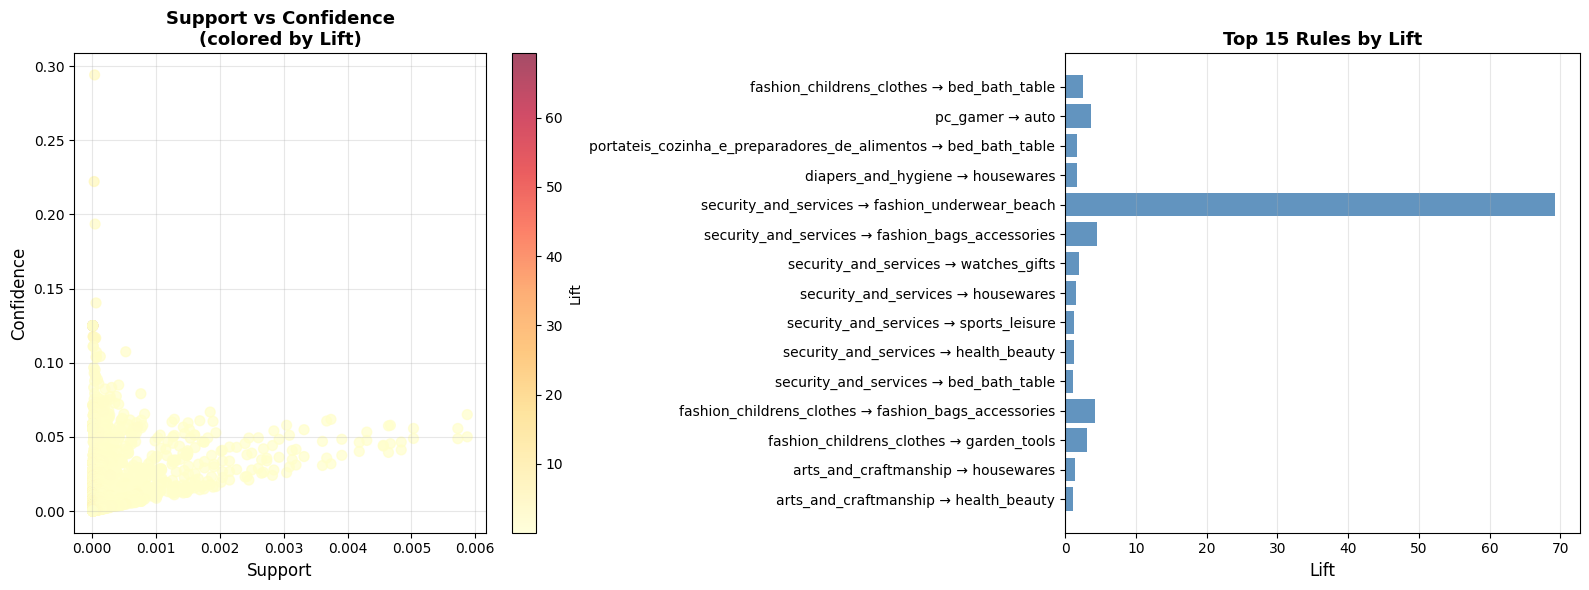

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(rules['support'], rules['confidence'],
                     c=rules['lift'], cmap='YlOrRd', alpha=0.7, s=50)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_title('Support vs Confidence\n(colored by Lift)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Support', fontsize=12)
axes[0].set_ylabel('Confidence', fontsize=12)
axes[0].grid(True, alpha=0.3)


top_rules = rules.head(15).copy()
top_rules['rule'] = top_rules['antecedents'].astype(str) + ' → ' + top_rules['consequents'].astype(str)
axes[1].barh(top_rules['rule'], top_rules['lift'], color='steelblue', alpha=0.85)
axes[1].set_title('Top 15 Rules by Lift', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lift', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:

def recommend_products(purchased_category, rules_df, top_n=5):
    purchased_category = purchased_category.lower().strip()

    mask = rules_df['antecedents'].str.lower().str.strip() == purchased_category
    matched = rules_df[mask].copy()


    matched = matched[matched['lift'] >= 1.0]

    if matched.empty:
        print(f"\n No strong recommendations found for '{purchased_category}'")
        print(f"   (No lift > 1 rules — try a less common category)")
        return

    matched = matched.sort_values('lift', ascending=False).head(top_n)

    print(f"\nCustomer bought: '{purchased_category}'")
    print(f"Top {top_n} Cross-sell Recommendations:")
    for _, row in matched.iterrows():
        print(f"   {row['consequents']}")
        print(f"     Confidence : {row['confidence']:.2%}")
        print(f"     Lift       : {row['lift']:.2f}")
 


print("RECOMMENDATION EXAMPLES")

top_categories = df_rec['category'].value_counts().head(3).index.tolist()
print(f"\nTesting with categories: {top_categories}\n")

for cat in top_categories:
    recommend_products(cat, rules, top_n=5)

print("\nTesting niche categories with stronger associations:")
for cat in ['security_and_services', 'pc_gamer', 'fashion_childrens_clothes']:
    recommend_products(cat, rules, top_n=5)

RECOMMENDATION EXAMPLES

Testing with categories: ['bed_bath_table', 'sports_leisure', 'health_beauty']


Customer bought: 'bed_bath_table'
Top 5 Cross-sell Recommendations:
   fashion_childrens_clothes
     Confidence : 0.03%
     Lift       : 2.50
   portateis_cozinha_e_preparadores_de_alimentos
     Confidence : 0.04%
     Lift       : 1.65
   security_and_services
     Confidence : 0.01%
     Lift       : 1.06

Customer bought: 'sports_leisure'
Top 5 Cross-sell Recommendations:
   security_and_services
     Confidence : 0.01%
     Lift       : 1.22
   pc_gamer
     Confidence : 0.01%
     Lift       : 1.08
   dvds_blu_ray
     Confidence : 0.12%
     Lift       : 1.01

Customer bought: 'health_beauty'
Top 5 Cross-sell Recommendations:
   security_and_services
     Confidence : 0.01%
     Lift       : 1.20
   arts_and_craftmanship
     Confidence : 0.05%
     Lift       : 1.12

Testing niche categories with stronger associations:

Customer bought: 'security_and_services'
Top 5 Cross

In [9]:
import os
os.makedirs('olist_augmented_data', exist_ok=True)


rules.to_csv('olist_augmented_data/association_rules.csv', index=False)

co_occurrence.to_csv('olist_augmented_data/co_occurrence_matrix.csv')

co_pairs.to_csv('olist_augmented_data/frequent_category_pairs.csv', index=False)

print("Saved: association_rules.csv")
print("Saved: co_occurrence_matrix.csv")
print("Saved: frequent_category_pairs.csv")

print(f"""

Model              : Co-occurrence + Association Rules
Level              : Product Category
Total Orders       : {basket_binary.shape[0]}
Total Categories   : {basket_binary.shape[1]}
Multi-cat Orders   : {len(multi_category_orders)} ({len(multi_category_orders)/len(basket_binary)*100:.1f}%)
Association Rules  : {len(rules)}

Top Rule by Confidence:
  {rules.iloc[0]['antecedents']} → {rules.iloc[0]['consequents']}
  Confidence : {rules.iloc[0]['confidence']:.2%}
  Lift       : {rules.iloc[0]['lift']:.2f}
""")

Saved: association_rules.csv
Saved: co_occurrence_matrix.csv
Saved: frequent_category_pairs.csv


Model              : Co-occurrence + Association Rules
Level              : Product Category
Total Orders       : 135312
Total Categories   : 74
Multi-cat Orders   : 26085 (19.3%)
Association Rules  : 3270

Top Rule by Confidence:
  fashion_childrens_clothes → bed_bath_table
  Confidence : 29.41%
  Lift       : 2.50

